# Academic Performance Model

This notebook predicts **`Second_Term_GPA`**:
- split data before fitting the preprocessor
- keep useful academic predictors such as `HS_Average` and `Math_Score`
- **drop `FirstYearPersistence`** to avoid leakage into the academic regression task
- save both the trained preprocessor and the trained Keras model for deployment


In [2]:

import os
import random
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:

# Load the dataset from a few common locations
possible_paths = [
    "./Student data.csv",
    "../data/Student data.csv",
    "/mnt/data/Student data.csv",
]

data_path = next((p for p in possible_paths if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find 'Student data.csv'. Put it in the notebook folder, ../data, or /mnt/data."
    )

columns = [
    "First_Term_GPA", "Second_Term_GPA", "First_Language", "Funding",
    "School", "FastTrack", "Coop", "Residency", "Gender",
    "Prev_Education", "Age_Group", "HS_Average", "Math_Score",
    "English_Grade", "FirstYearPersistence"
]

data = pd.read_csv(data_path, skiprows=24, header=None, na_values="?")
data.columns = columns

print("Loaded:", data_path)
print("Shape:", data.shape)
data.head()


Loaded: ./Student data.csv
Shape: (1437, 15)


,First_Term_GPA,Second_Term_GPA,First_Language,Funding,School,FastTrack,Coop,Residency,Gender,Prev_Education,Age_Group,HS_Average,Math_Score,English_Grade,FirstYearPersistence
0,0.000000,0.000000,1.0,2,6,2,1,1,2,1.0,1.0,59.0,16.0,7.0,1
1,2.500000,2.000000,3.0,4,6,1,2,2,2,1.0,3.0,NaN,NaN,7.0,1
2,4.250000,3.923077,1.0,1,6,2,1,1,1,2.0,3.0,92.0,41.0,9.0,1
3,3.020833,2.321429,3.0,4,6,1,2,2,2,2.0,3.0,NaN,NaN,8.0,1
4,4.275000,4.326923,1.0,2,6,1,1,1,1,2.0,3.0,97.0,NaN,9.0,1


In [4]:

# Basic cleaning
for col in ["First_Term_GPA", "Second_Term_GPA", "HS_Average", "Math_Score"]:
    data[col] = pd.to_numeric(data[col], errors="coerce")

# Remove rows where the target is missing
data = data.dropna(subset=["Second_Term_GPA","FirstYearPersistence"]).copy()

missing_summary = pd.DataFrame({
    "Missing Values": data.isna().sum(),
    "Percentage Missing": (data.isna().mean() * 100).round(2)
})
missing_summary


,Missing Values,Percentage Missing
First_Term_GPA,0,0.00
Second_Term_GPA,0,0.00
First_Language,104,8.14
Funding,0,0.00
School,0,0.00
FastTrack,0,0.00
Coop,0,0.00
Residency,0,0.00
Gender,0,0.00
Prev_Education,3,0.23


## Feature selection

`Second_Term_GPA` is the target.  
`FirstYearPersistence` is excluded from the academic model because it can leak later-outcome information into the GPA prediction task.


In [6]:

target_column = "Second_Term_GPA"

numeric_features = ["First_Term_GPA", "HS_Average", "Math_Score"]


categorical_features = [
    "First_Language",
    "Funding",
    "School",
    "FastTrack",
    "Coop",
    "Residency",
    "Gender",
    "Prev_Education",
    "Age_Group",
    "English_Grade",
]

feature_columns = numeric_features + categorical_features

X = data[feature_columns].copy()
y = data[target_column].copy()

print("Feature columns:", feature_columns)
print("Target column:", y)


Feature columns: ['First_Term_GPA', 'HS_Average', 'Math_Score', 'First_Language', 'Funding', 'School', 'FastTrack', 'Coop', 'Residency', 'Gender', 'Prev_Education', 'Age_Group', 'English_Grade']
Target column: 0       0.000000
1       2.000000
2       3.923077
3       2.321429
4       4.326923
          ...   
1432    0.000000
1433    4.074074
1434    2.450000
1435    4.357143
1436    3.205882
Name: Second_Term_GPA, Length: 1277, dtype: float64


In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED
)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Convert sparse matrices to dense arrays for Keras if needed
if hasattr(X_train_processed, "toarray"):
    X_train_processed = X_train_processed.toarray()
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

input_dim = X_train_processed.shape[1]
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)


Processed training shape: (1021, 40)
Processed test shape: (256, 40)


In [8]:

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.1),
    Dense(1, activation="linear"),
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping],
    verbose=1
)


Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 3.8811 - mae: 1.6716 - val_loss: 1.0095 - val_mae: 0.7646
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0572 - mae: 0.8055 - val_loss: 0.5819 - val_mae: 0.5543
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7405 - mae: 0.6775 - val_loss: 0.5158 - val_mae: 0.5425
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6734 - mae: 0.6439 - val_loss: 0.4949 - val_mae: 0.5311
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6585 - mae: 0.6360 - val_loss: 0.4728 - val_mae: 0.5018
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6214 - mae: 0.6219 - val_loss: 0.4762 - val_mae: 0.5102
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6221 - mae: 0.6142 - val_loss: 0.4751 - val_mae: 0.5130
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5957 - mae: 0.5970 - val_loss: 0.4735 - val_mae: 0.4981
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.585

In [10]:

test_loss, test_mae = model.evaluate(X_test_processed, y_test, verbose=0)
y_pred = model.predict(X_test_processed, verbose=0).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Test Loss (MSE): {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2 Score: {r2:.4f}")


Test Loss (MSE): 0.3578
Test MAE: 0.4685
RMSE: 0.5982
R2 Score: 0.6756


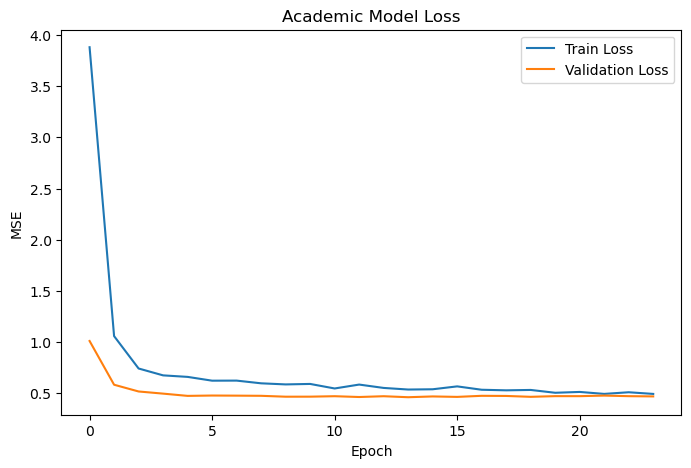

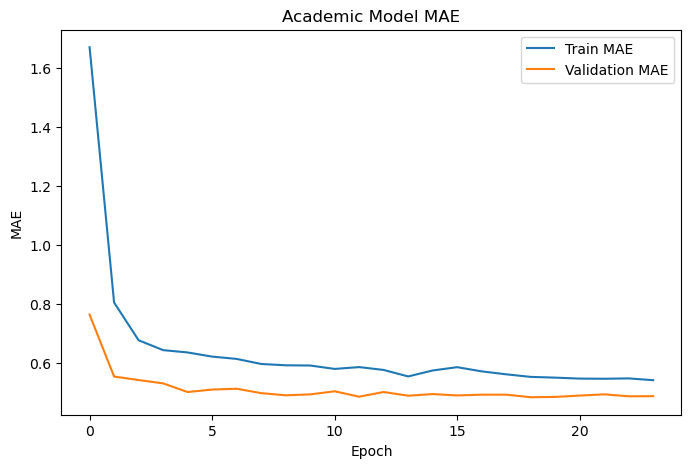

In [11]:

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Academic Model Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["mae"], label="Train MAE")
plt.plot(history.history["val_mae"], label="Validation MAE")
plt.title("Academic Model MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()


In [12]:

output_dir = "./output"
os.makedirs(output_dir, exist_ok=True)

preprocessor_path = os.path.join(output_dir, "academic_preprocessor.pkl")
model_path = os.path.join(output_dir, "academic_model.h5")

joblib.dump(preprocessor, preprocessor_path)
model.save(model_path)

print("Saved preprocessor to:", preprocessor_path)
print("Saved model to:", model_path)


Saved preprocessor to: ./output\academic_preprocessor.pkl
Saved model to: ./output\academic_model.h5


## Notes

- no dropping of `HS_Average` and `Math_Score` even though there is alot of missing data
- no use of `FirstYearPersistence` in the academic regression model
- preprocessing is fit only on the training split
- output artifacts are saved for backend deployment
